In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from rebar_object_detection import get_bounding_boxes, get_lines
import json

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 29, 31]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 29, 31]


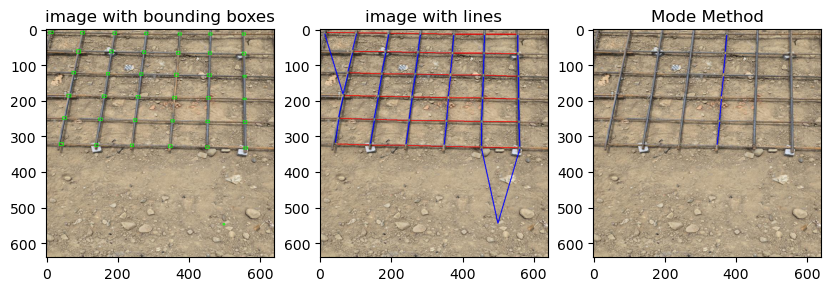

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1

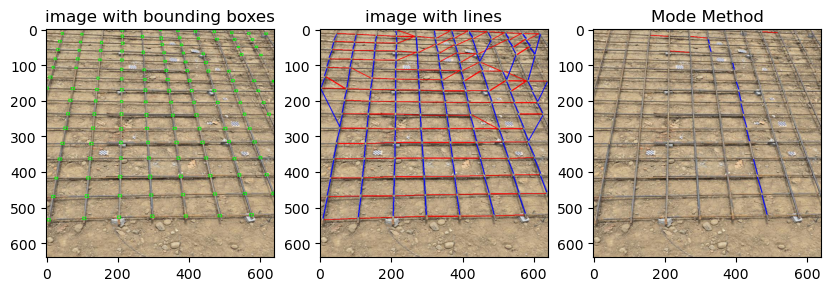

[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 32, 35, 37, 39, 40, 41]
[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 32, 35, 37, 39, 40, 41]
[0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36]
[0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36]


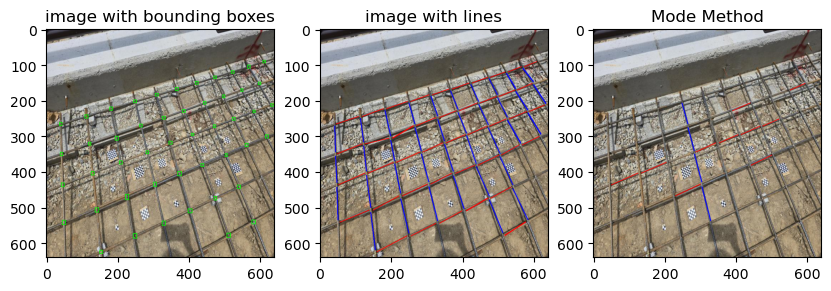

In [3]:
image_paths = [
    "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg",
    "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg",
    "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg",
]
model_path = "runs/detect/tune/weights/best.pt"


# Draw bounding boxes
def draw_bounding_boxes(image_path, model_path):
    image = Image.open(image_path)
    draw_boxes = ImageDraw.Draw(image)

    bounding_boxes = get_bounding_boxes(image, model_path)
    for box in bounding_boxes:
        draw_boxes.rectangle([box[0], box[1], box[2], box[3]], outline="lime", width=2)

    return image


# Draw lines
def draw_lines(image_path, model_path, threshold=1.5):
    image = Image.open(image_path).copy()
    draw_lines = ImageDraw.Draw(image)

    json_data = get_lines(image_path, model_path, threshold=threshold)
    data = json.loads(json_data)
    for shape in data["shapes"]:
        points = shape["points"]
        color = "red" if shape["orientation"] == "horizontal" else "blue"
        draw_lines.line([tuple(points[0]), tuple(points[1])], fill=color, width=3)

    return image


def show_result(image_path, model_path):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("image with bounding boxes")
    plt.imshow(draw_bounding_boxes(image_path, model_path))
    plt.subplot(1, 3, 2)
    plt.title("image with lines")
    plt.imshow(draw_lines(image_path, model_path, threshold=0))
    plt.subplot(1, 3, 3)
    plt.title("Mode Method")
    plt.imshow(draw_lines(image_path, model_path))
    plt.show()


for path in image_paths:
    show_result(path, model_path)
